In [2]:
import pandas as pd
import seaborn as sns
import matplotlib .pyplot as plt

print("All libraries are downloaded")

All libraries are downloaded


In [3]:
# Read the csv and print the head
df = pd.read_csv("../data/cleaned/properties_final.csv")
df.head

<bound method NDFrame.head of       property_type property_subtype     price  living_area_m2  bedrooms  \
0             House        residence  550000.0           250.0       4.0   
1         Apartment        apartment  200000.0            57.0       1.0   
2         Apartment           duplex  189000.0           115.0       1.0   
3             House        residence  549000.0           399.0       3.0   
4             House        residence  330000.0            99.0       3.0   
...             ...              ...       ...             ...       ...   
12617     Apartment        apartment  240000.0            78.0       2.0   
12618         House        residence  274000.0           228.0       6.0   
12619         House        residence  749000.0           380.0       6.0   
12620         House        residence  220000.0           211.0       3.0   
12621         House        residence  739000.0           314.0       5.0   

       bathrooms                     address  postal_code

In [4]:
# finding what type of data is there in our file
df.dtypes

# Finding only the numeric values
df.select_dtypes(include='number').columns



Index(['price', 'living_area_m2', 'bedrooms', 'bathrooms', 'postal_code',
       'latitude', 'longitude', 'building_year', 'furnished', 'has_garage',
       'parking_count', 'has_elevator', 'facades', 'floors_total',
       'has_garden', 'garden_area_m2', 'has_terrace', 'total_area_m2',
       'km_from_nearby_city', 'is_nearby_city_prestigious', 'floor_number',
       'price_per_m2'],
      dtype='str')

In [5]:
# Selecting the numeric value which will affect the output
numeric_columns = ['price','living_area_m2','bedrooms','bathrooms', 
       'building_year', 'furnished', 'has_garage',
       'parking_count', 'has_elevator', 'facades', 
       'has_garden',  'has_terrace', 
       'is_nearby_city_prestigious'
       ]
# Making a smaller dataframe with the above columns, dropping the rows which do not have price
# as it will directly affect our corelation
df_corr = df[numeric_columns].dropna(subset = ['price'])
df_corr.shape  #209 rows dropped as it did not have the data


(12399, 13)

In [6]:
#Finding the correlation between all the columns with price column
correlation = df_corr.corr()['price'].sort_values(ascending = False)
print(correlation)

price                         1.000000
living_area_m2                0.597580
bedrooms                      0.543743
bathrooms                     0.516123
facades                       0.254577
has_garage                    0.192087
has_garden                    0.177404
is_nearby_city_prestigious    0.151287
has_terrace                   0.112440
building_year                 0.073629
furnished                    -0.004973
parking_count                -0.008772
has_elevator                 -0.052963
Name: price, dtype: float64


In [7]:
#Finding why has_garage comes to NaN
df_corr['has_garage'].value_counts(dropna= False)

# Because 'has_garage' has NaN values more than the half and also no 0 values are there
#there cannot be any correlation between this value and price, so we will drop this.

has_garage
0    6804
1    5595
Name: count, dtype: int64

In [22]:
# Removed has_garage
numeric_columns = ['price','living_area_m2','bedrooms','bathrooms', 
       #'building_year', 'furnished',
       #'parking_count', 'has_elevator', 
       'facades', 
       'has_garden',  'has_terrace', 
       'is_nearby_city_prestigious'
       ]
df_corr = df[numeric_columns].dropna(subset = ['price'])       
correlation = df_corr.corr()['price'].sort_values(ascending = False)
print(correlation)

price                         1.000000
living_area_m2                0.597580
bedrooms                      0.543743
bathrooms                     0.516123
facades                       0.254577
has_garden                    0.177404
is_nearby_city_prestigious    0.151287
has_terrace                   0.112440
Name: price, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

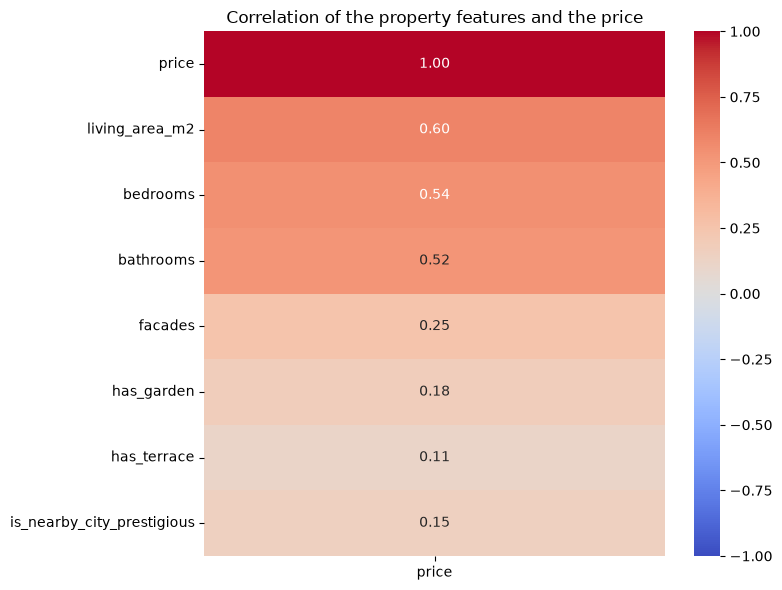

In [23]:
plt.figure(figsize=(8,6))  #size of the chart
sns.heatmap(
    df_corr.corr()[['price']],
    annot = True,        # show the number inside the boxes
    fmt = '.2f',         # round to 2 decimal places
    cmap = 'coolwarm',   # red for positive and blue for negative
    vmin = -1,           # goes from -1 to 1
    vmax = 1
)
plt.title("Correlation of the property features and the price")
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show

## Question: What is the correlation between the variables and the price? Why do you think some variables are more correlated than others?
 The correlation between the prpoerty and its prices lies between 1 - -0.05. 
 Some variables are more correlated than others as they affect the property prices directly like the living area etc.
 We excluded the building_year,furnished,parking_count,has elevator features with 0.07, 0.00, -0.01, -0.05 correlation respectively  with price as it did not affect the price much.

## "What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? in terms of:
price per m²
average price
median price

In [10]:
# "What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? in terms of:
# price per m²
# average price
# median price
df['price_per_m2'] = df['price']/df ['living_area_m2'] # Creating a new column with the divided values
df[['city','price','living_area_m2','price_per_m2']].head(10) # Checking if the new column was created

,city,price,living_area_m2,price_per_m2
0,Flemalle,550000.0,250.0,2200.000000
1,Elsene,200000.0,57.0,3508.771930
2,Tournai,189000.0,115.0,1643.478261
3,Eksel,549000.0,399.0,1375.939850
4,La Roche En Ardenne,330000.0,99.0,3333.333333
5,Sint Lambrechts Woluwe,860000.0,240.0,3583.333333
6,Chapelle Lez Herlaimont,194000.0,180.0,1077.777778
7,Namur,650000.0,800.0,812.500000
8,Durbuy,85000.0,34.0,2500.000000
9,Binderveld,795000.0,232.0,3426.724138


In [11]:
city_stats = df.groupby('city').agg(
    avg_price = ('price', 'mean'),
    median_price = ('price','median'),
    avg_price_per_m2 = ('price_per_m2','mean'),
    count = ('price','count')
).reset_index()

# Cities with 5 properties
city_stats = city_stats[city_stats['count']>=5]  # Filtering with the count greater than 5
#city_val = city_val.reset_index(drop=True) # This will reset the numbers in the columns

city_stats.head(10)

,city,avg_price,median_price,avg_price_per_m2,count
2,Aalst,459346.981481,327000.0,2542.716293,54
3,Aalter,557264.928571,470500.0,2913.560131,14
4,Aarschot,478166.666667,446500.0,2662.132311,6
12,Affligem,361000.000000,362000.0,2270.990147,6
16,Aiseau Presles,208857.142857,199000.0,1521.617366,7
17,Alken,457300.000000,457500.0,2071.886083,10
22,Amay,220561.888889,199000.0,1760.970991,27
26,Amel,380900.000000,371500.0,3145.655775,10
27,Amonines,315083.333333,194500.0,1849.998475,6
30,Andenne,266547.916667,236500.0,2099.700825,60


In [12]:

print("Top 5 most expensive cities(Average Price)")
print(city_stats.nlargest(5,'avg_price')[['city','avg_price','count']])

print("\n5 least expensive cities(Average Price)")
print(city_stats.nsmallest(5,'avg_price')[['city','avg_price','count']])

Top 5 most expensive cities(Average Price)
              city     avg_price  count
779       Kraainem  1.362500e+06     12
1368    Sterrebeek  1.269931e+06     12
556   Grez Doiceau  1.158230e+06     16
767   Knokke Heist  1.132544e+06     33
389       Eernegem  1.104500e+06      6

5 least expensive cities(Average Price)
                   city      avg_price  count
176            Blaimont   76892.857143     28
88              Baileux   83737.500000      8
607   Hastiere Par Dela  106250.000000      8
1518             Wasmes  112285.714286      7
606     Hastiere Lavaux  117330.769231     13


In [13]:
flanders = df[df['region'] == 'Flanders']
wallonia = df[df['region'] == 'Wallonia']
brussels = df[df['region'] == 'Brussels']

In [14]:
def city_stats_by_region(region_df):
    stats = region_df.groupby('city').agg(
    avg_price = ('price', 'mean'),
    median_price = ('price','median'),
    avg_price_per_m2 = ('price_per_m2','mean'),
    count = ('price','count')
).reset_index()
    return stats[stats['count']>=5]

flanders_stats = city_stats_by_region(flanders)
wallonia_stats = city_stats_by_region(wallonia)
brussels_stats = city_stats_by_region(brussels)


In [15]:
print("Top 5 most expensive cities(Average Price)")
print(flanders_stats.nlargest(5,'avg_price')[['city','avg_price','count']])

print("\n5 least expensive cities(Average Price)")
print(flanders_stats.nsmallest(5,'avg_price')[['city','avg_price','count']])

print("Top 5 most expensive cities(Average Price)")
print(wallonia_stats.nlargest(5,'avg_price')[['city','avg_price','count']])

print("\n5 least expensive cities(Average Price)")
print(wallonia_stats.nsmallest(5,'avg_price')[['city','avg_price','count']])

Top 5 most expensive cities(Average Price)
                city     avg_price  count
276         Kraainem  1.362500e+06     12
504       Sterrebeek  1.269931e+06     12
265     Knokke Heist  1.132544e+06     33
138         Eernegem  1.104500e+06      6
571  Wezembeek Oppem  1.081111e+06      9

5 least expensive cities(Average Price)
         city      avg_price  count
204   Herselt  161600.000000      5
562    Wervik  192400.000000     22
88    Bredene  195107.692308     13
563  Westende  198257.692308     26
438    Rekkem  203818.181818     11
Top 5 most expensive cities(Average Price)
                city     avg_price  count
380     Grez Doiceau  1.158230e+06     16
810          Seneffe  1.096286e+06      7
146  Braine L Alleud  9.635294e+05     17
497         La Hulpe  9.221667e+05      6
508            Lasne  8.077501e+05     16

5 least expensive cities(Average Price)
                  city      avg_price  count
108           Blaimont   76892.857143     28
57             Baileux

In [16]:
print(wallonia_stats.nsmallest(5, 'avg_price')[['city', 'avg_price', 'count']])

                  city      avg_price  count
108           Blaimont   76892.857143     28
57             Baileux   83737.500000      8
414  Hastiere Par Dela  106250.000000      8
944             Wasmes  112285.714286      7
413    Hastiere Lavaux  117330.769231     13


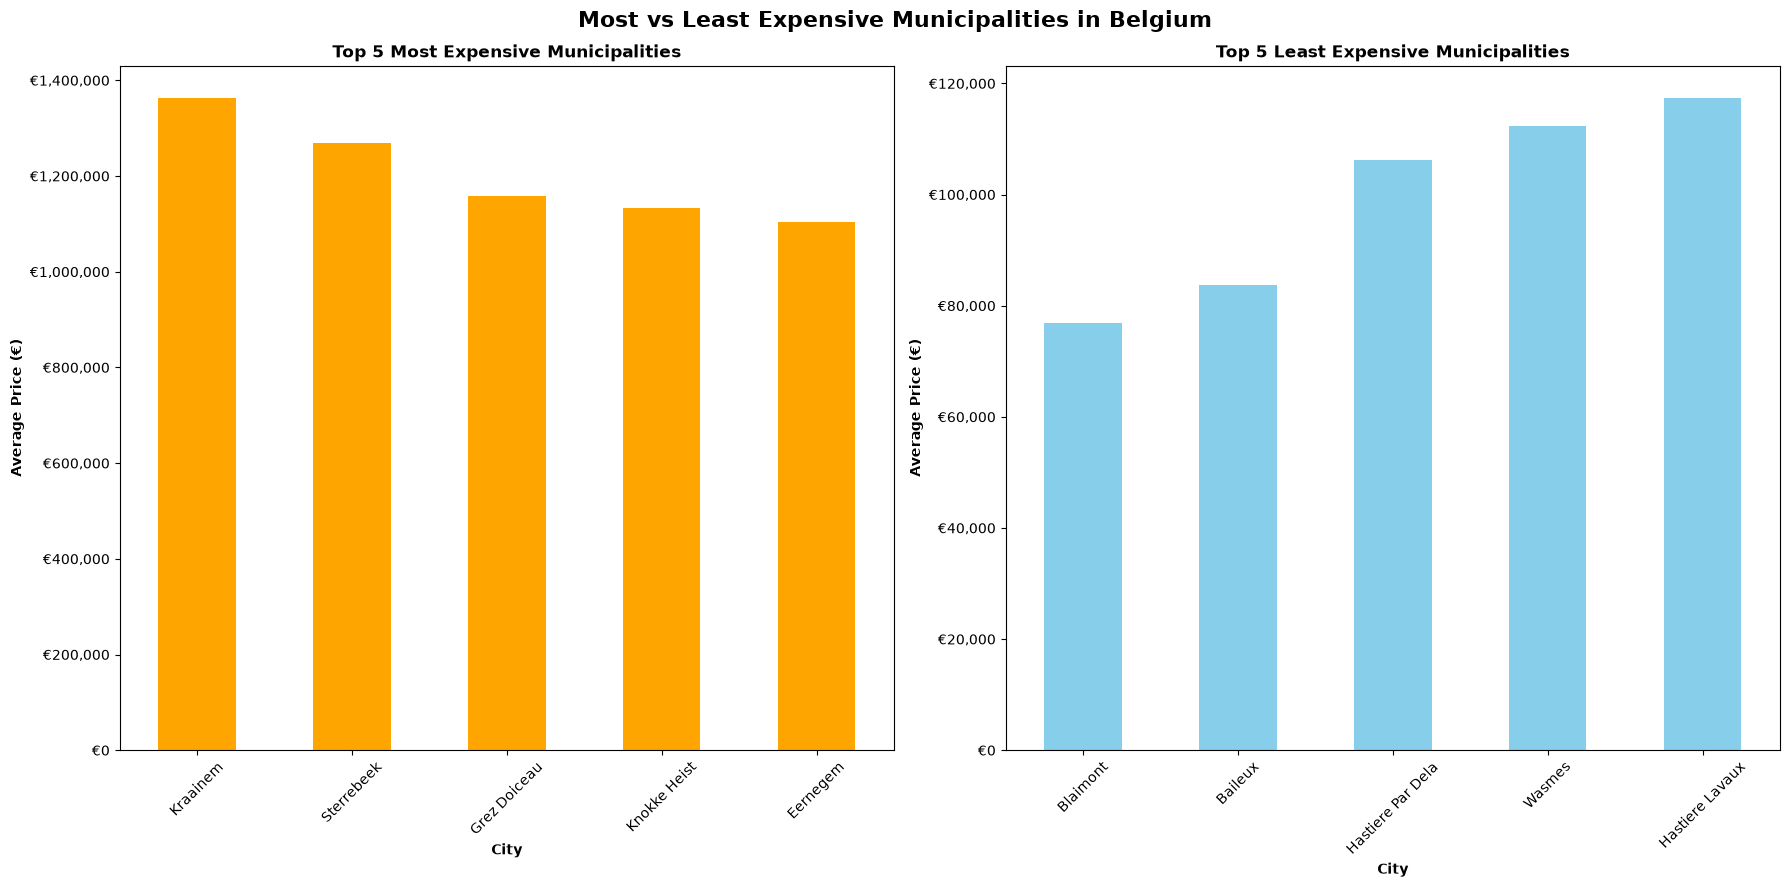

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Most expensive in Belgium
city_stats.nlargest(5, 'avg_price').plot(
    kind='bar', x='city', y='avg_price', 
    ax=axes[0], color='orange', legend=False , 
)
axes[0].set_title('Top 5 Most Expensive Municipalities', fontweight="bold")
axes[0].set_xlabel('City', fontweight="bold")
axes[0].set_ylabel('Average Price (€)', fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)

# Least expensive in Belgium
city_stats.nsmallest(5, 'avg_price').plot(
    kind='bar', x='city', y='avg_price', 
    ax=axes[1], color='skyblue', legend=False , 
)
axes[1].set_title('Top 5 Least Expensive Municipalities',fontweight="bold")
axes[1].set_xlabel('City', fontweight="bold")
axes[1].set_ylabel('Average Price (€)', fontweight="bold")
axes[1].tick_params(axis='x', rotation=45)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
)
plt.suptitle('Most vs Least Expensive Municipalities in Belgium',fontsize = 16,fontweight="bold")
plt.tight_layout()
plt.savefig('../images/municipality_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## Most expensive and least expensive municipalities in Belgium
As from the image we see, Kraainem is  the most expensive Municipality in Belgium
The least expensive being  Blaimont

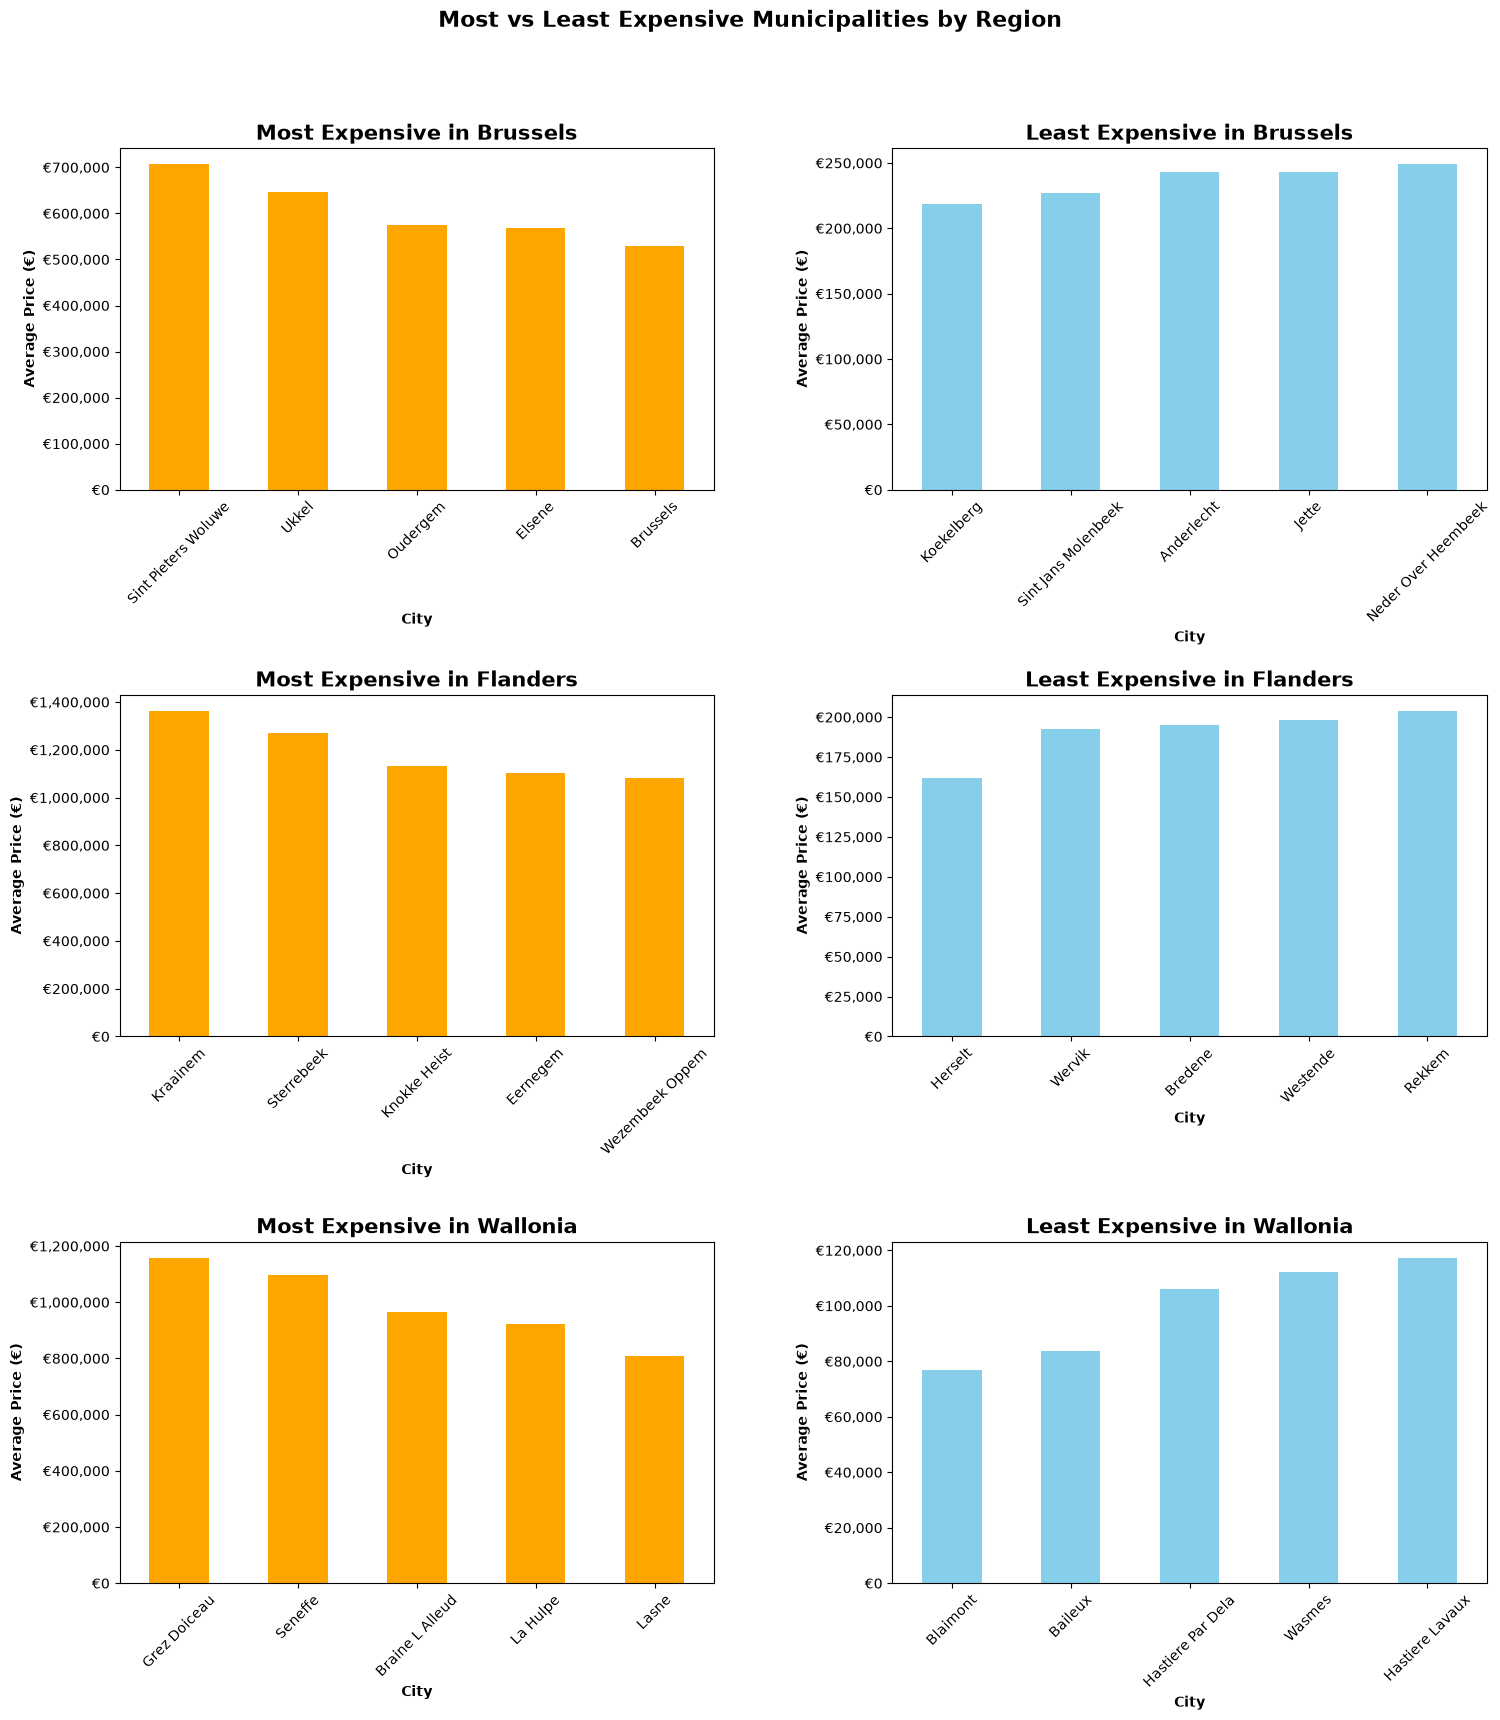

In [18]:
fig, axes = plt.subplots(3, 2, figsize= (16,18))
regions = [('Brussels',brussels_stats),
('Flanders',flanders_stats),
('Wallonia',wallonia_stats)
]
for i, (region_name, stats) in enumerate(regions):
    # Most Expensive
    stats.nlargest(5, 'avg_price').plot(kind='bar',x = 'city', y = 'avg_price', 
    ax = axes[i][0], color = 'orange', legend=False,
    )

    axes[i][0].set_title(f'Most Expensive in {region_name}')
    axes[i][0].set_title(f'Most Expensive in {region_name}', fontsize=15, fontweight="bold")
    axes[i][0].set_xlabel('City',fontweight = "bold")
    axes[i][0].set_ylabel('Average Price (€)',fontweight = "bold")
    axes[i][0].tick_params(axis = 'x', rotation = 45)
    axes[i][0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    # Least Expensive
    stats.nsmallest(5, 'avg_price').plot(kind='bar',x = 'city', y = 'avg_price', 
    ax = axes[i][1], color = 'skyblue', legend=False , 
    )

    axes[i][1].set_title(f'Least Expensive in {region_name}')
    axes[i][1].set_title(f'Least Expensive in {region_name}', fontsize=15, fontweight="bold")
    axes[i][1].set_xlabel('City', fontweight = "bold")
    axes[i][1].set_ylabel('Average Price (€)', fontweight = "bold")
    axes[i][1].tick_params(axis = 'x', rotation = 45)
    axes[i][1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    plt.suptitle('Most vs Least Expensive Municipalities by Region', fontsize = 16, fontweight = "bold")
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.savefig('../images/municipality_prices_by_region.png', dpi=150, bbox_inches='tight')
    plt.show


## Average price comparison with the Regions
As seen from the example above Kraainem stands as the highest in the list for most expensive in Belgium and 

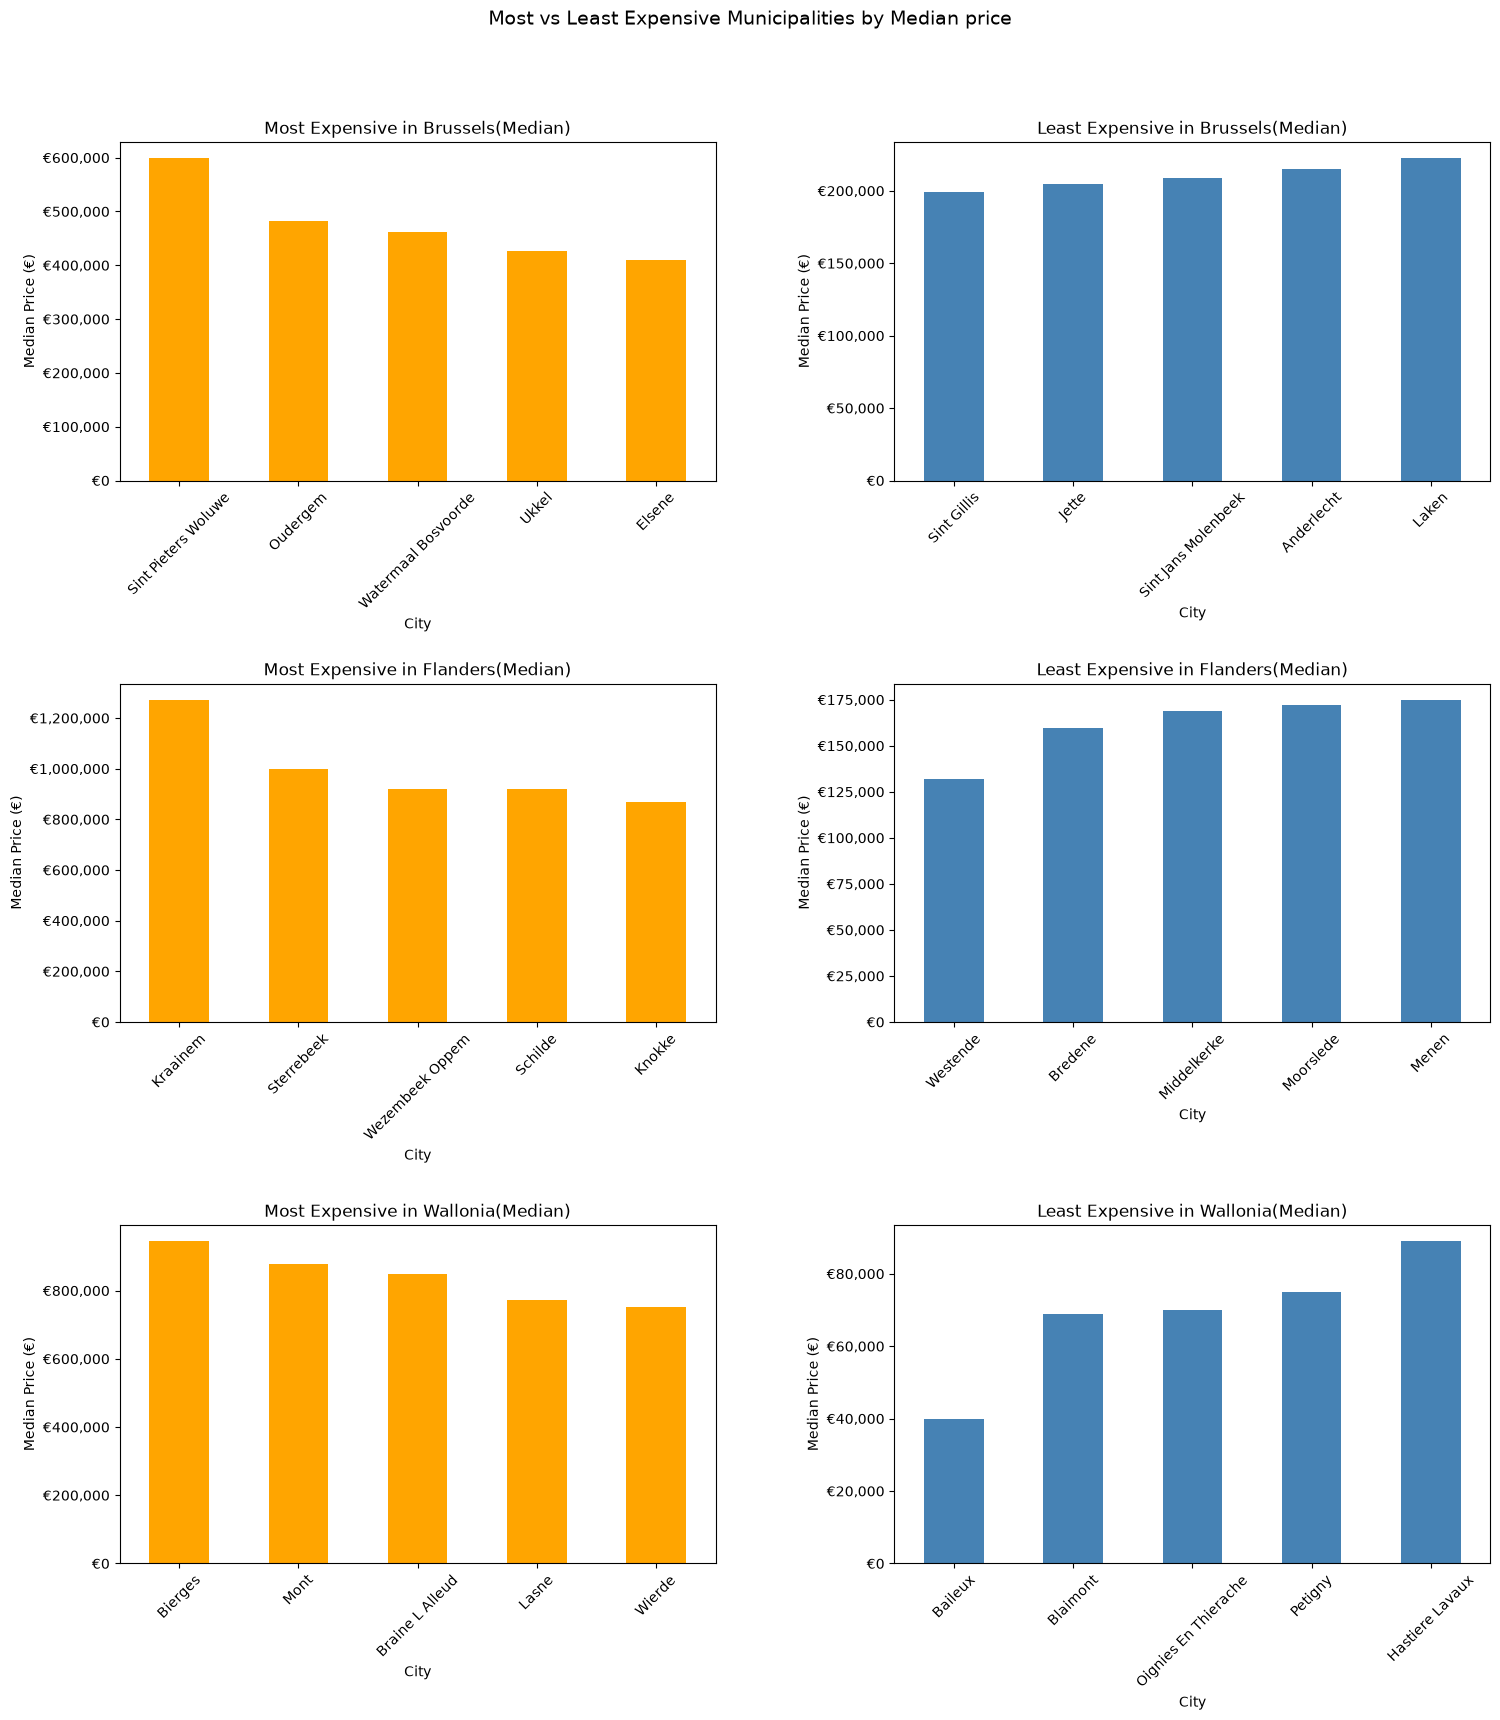

In [19]:
# Charts for median of the municipalities
fig, axes = plt.subplots(3, 2, figsize= (16,18))
regions = [('Brussels',brussels_stats),
('Flanders',flanders_stats),
('Wallonia',wallonia_stats)
]
for i, (region_name, stats) in enumerate(regions):
    # Most Expensive
    stats.nlargest(5, 'median_price').plot(kind='bar',x = 'city', y = 'median_price', 
    ax = axes[i][0], color = 'orange', legend=False
    )

    axes[i][0].set_title(f'Most Expensive in {region_name}(Median)')
    axes[i][0].set_xlabel('City')
    axes[i][0].set_ylabel('Median Price (€)')
    axes[i][0].tick_params(axis = 'x', rotation = 45)
    axes[i][0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    # Least Expensive
    stats.nsmallest(5, 'median_price').plot(kind='bar',x = 'city', y = 'median_price', 
    ax = axes[i][1], color = 'steelblue', legend=False
    )

    axes[i][1].set_title(f'Least Expensive in {region_name}(Median)')
    axes[i][1].set_xlabel('City')
    axes[i][1].set_ylabel('Median Price (€)')
    axes[i][1].tick_params(axis = 'x', rotation = 45)
    axes[i][1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    plt.suptitle('Most vs Least Expensive Municipalities by Median price', fontsize = 14)
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.savefig('../images/municipality_prices_by_region.png', dpi=150, bbox_inches='tight')
    plt.show


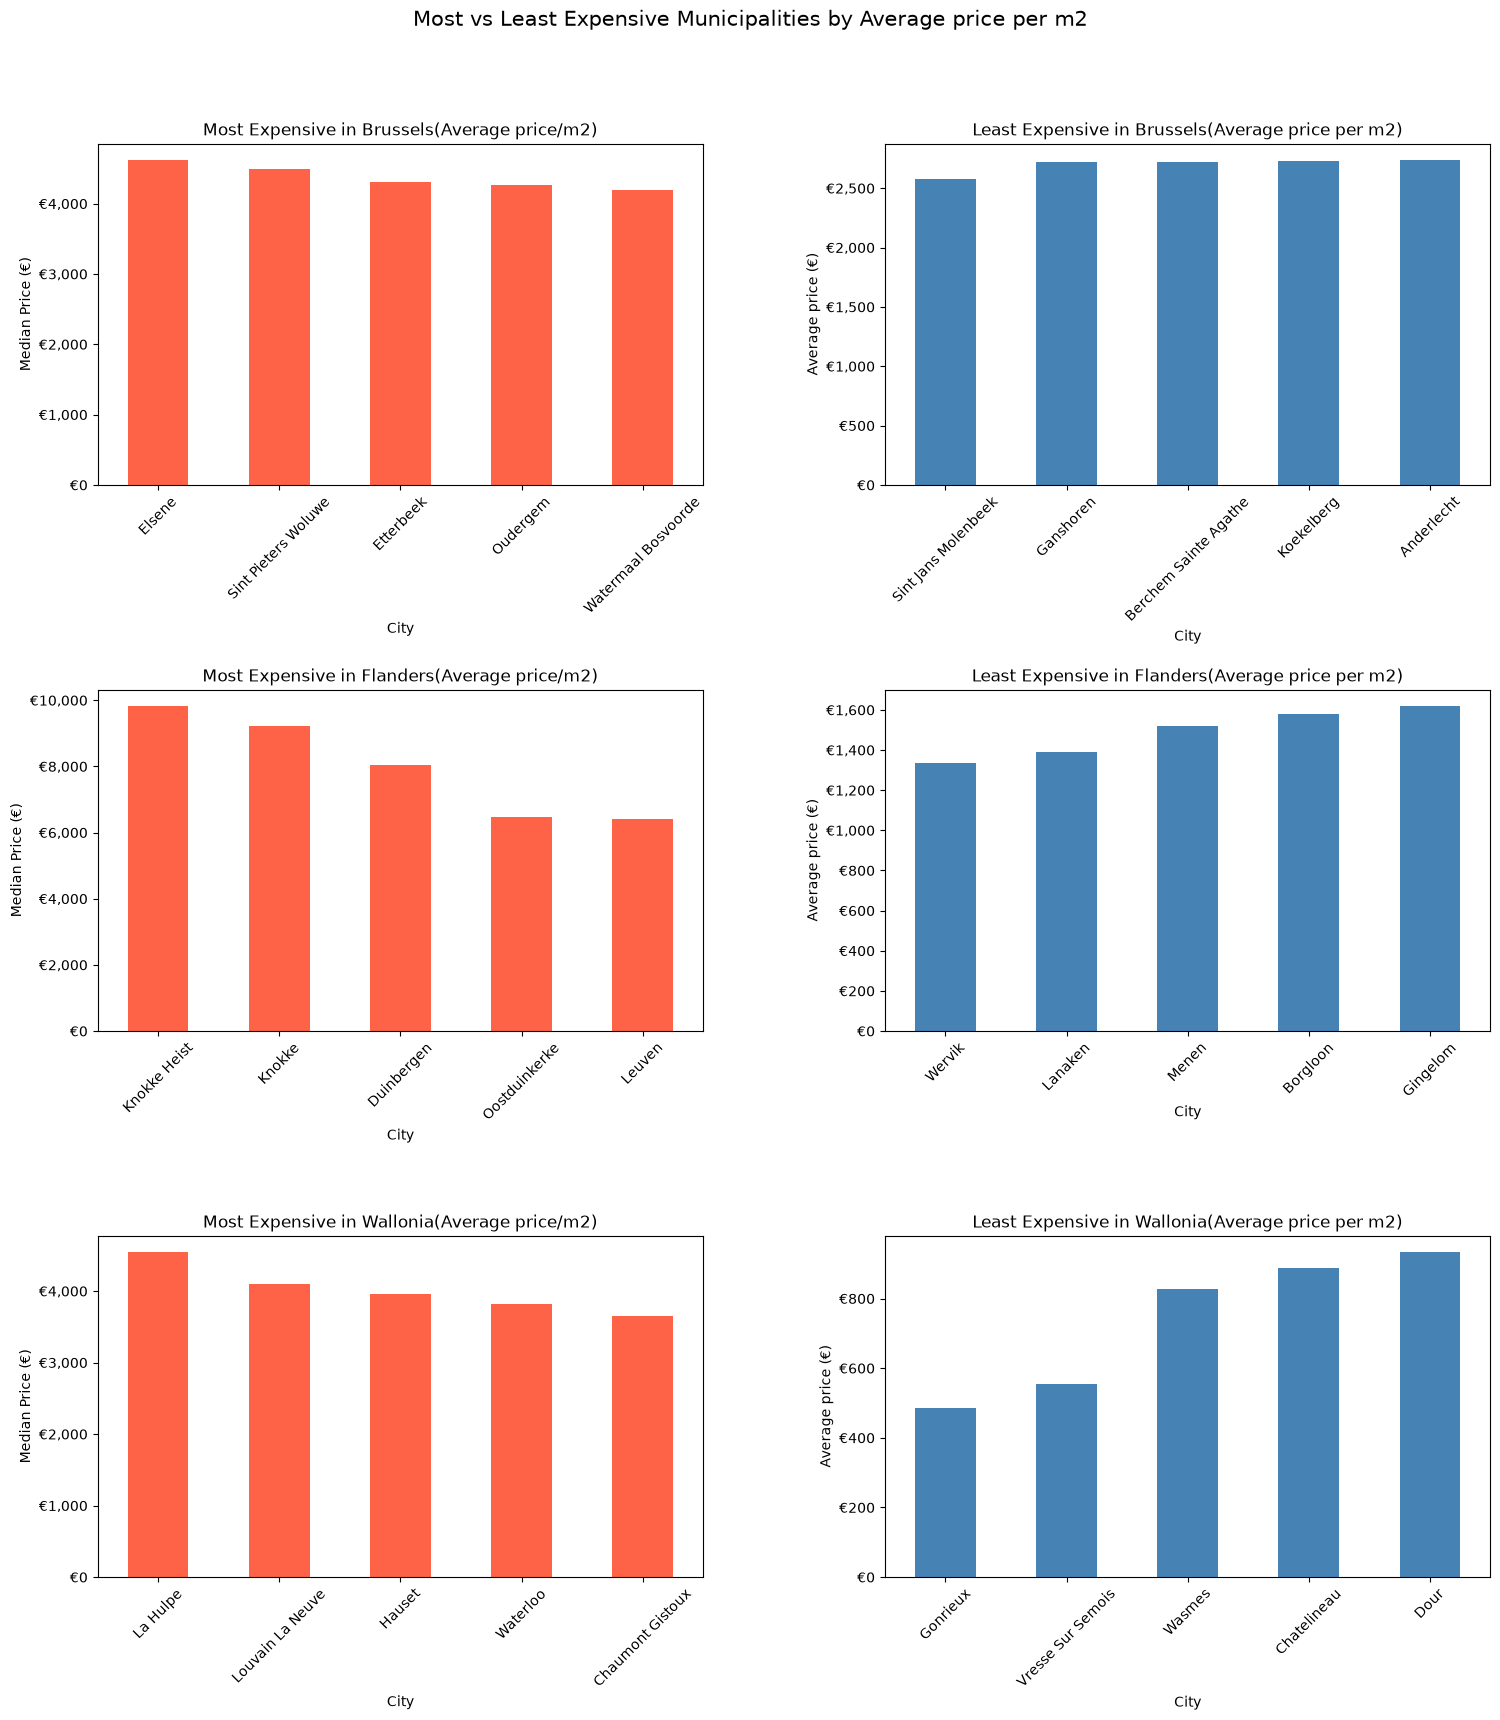

In [ ]:
# Charts for price_per_m2 of the municipalities
fig, axes = plt.subplots(3, 2, figsize= (16,18))
regions = [('Brussels',brussels_stats),
('Flanders',flanders_stats),
('Wallonia',wallonia_stats)
]
for i, (region_name, stats) in enumerate(regions):
    # Most Expensive
    stats.nlargest(5, 'avg_price_per_m2').plot(kind='bar',x = 'city', y = 'avg_price_per_m2', 
    ax = axes[i][0], color = 'tomato', legend=False
    )

    axes[i][0].set_title(f'Most Expensive in {region_name}(Average price/m2)')
    axes[i][0].set_xlabel('City')
    axes[i][0].set_ylabel('Median Price (€)')
    axes[i][0].tick_params(axis = 'x', rotation = 45)
    axes[i][0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    # Least Expensive
    stats.nsmallest(5, 'avg_price_per_m2').plot(kind='bar',x = 'city', y = 'avg_price_per_m2', 
    ax = axes[i][1], color = 'steelblue', legend=False
    )

    axes[i][1].set_title(f'Least Expensive in {region_name}(Average price per m2)')
    axes[i][1].set_xlabel('City')
    axes[i][1].set_ylabel('Average price (€)')
    axes[i][1].tick_params(axis = 'x', rotation = 45)
    axes[i][1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    plt.suptitle('Most vs Least Expensive Municipalities by Average price per m2', fontsize = 15)
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.savefig('../images/municipality_.png', dpi=150, bbox_inches='tight')
    plt.show


In [21]:
print(df[df['city'] == 'stavelot'][['city', 'price', 'living_area_m2', 'price_per_m2']])

Empty DataFrame
Columns: [city, price, living_area_m2, price_per_m2]
Index: []
